<a href="https://colab.research.google.com/github/ShanmughapriyaM/Applied-Machine-Learning/blob/main/Unit2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving a 220 Hz sine wave to /content/sample_data/sine_wave2.wav...
File '/content/sample_data/sine_wave2.wav' saved successfully.


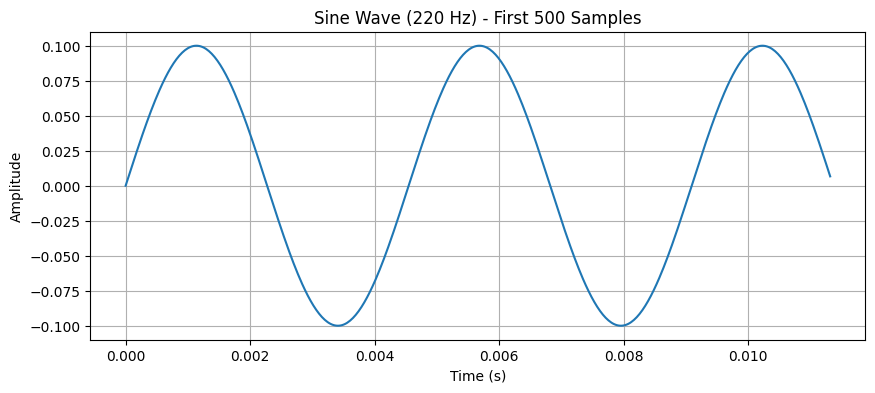

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import write as write_wav # Import the write function

# Audio parameters
sampling_rate = 44100  # samples per second (Hz)
duration = 2           # seconds
frequency = 220        # Hz (A4 note)
amplitude = 0.1       # between 0.0 and 1.0

# Generate time axis
t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)

# Construct the audio samples (sine wave)
audio_samples = amplitude * np.sin(2 * np.pi * frequency * t)

# --- Save to WAV file ---
# For WAV files, audio data typically needs to be in an integer format.
# A common format is 16-bit PCM (Pulse Code Modulation), where values
# range from -32768 to 32767.
# We scale our float samples (which are between -amplitude and +amplitude)
# to this integer range.
scaled_audio = np.int16(audio_samples / np.max(np.abs(audio_samples)) * 32767)

output_filename = "/content/sample_data/sine_wave2.wav"

print(f"Saving a {frequency} Hz sine wave to {output_filename}...")
write_wav(output_filename, sampling_rate, scaled_audio)

print(f"File '{output_filename}' saved successfully.")

# You can also play it back directly in Colab after saving (optional)
# from IPython.display import Audio
# Audio(output_filename) # Uncomment to play the saved file in Colab

# Plot a small portion of the waveform to visualize
plt.figure(figsize=(10, 4))
plt.plot(t[:500], audio_samples[:500]) # Plot first 500 samples
plt.title(f"Sine Wave ({frequency} Hz) - First 500 Samples")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from scipy.io.wavfile import write as write_wav # Import the write function
import matplotlib.pyplot as plt

def synthesize_note(frequency, duration, amplitude, sampling_rate=44100):
    """
    Generates a simple sine wave audio signal for a given frequency, duration, and amplitude.

    Args:
        frequency (float): The desired frequency of the note in Hz.
        duration (float): The duration of the note in seconds.
        amplitude (float): The peak amplitude of the wave (0.0 to 1.0).
        sampling_rate (int): The number of samples per second (Hz).

    Returns:
        np.ndarray: A NumPy array representing the audio waveform.
    """
    time_points = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
    # The core of synthesis: amplitude * sin(2 * pi * frequency * time)
    waveform = amplitude * np.sin(2 * np.pi * frequency * time_points)
    return waveform

# --- Example Usage of Synthesizer Function ---
sr = 44100  # Sampling rate
note_a4 = synthesize_note(frequency=440, duration=1.5, amplitude=0.6, sampling_rate=sr)
note_c5 = synthesize_note(frequency=523.25, duration=1.0, amplitude=0.5, sampling_rate=sr)

# Convert to 16-bit integers
note_a4_int16 = (note_a4 * 32767).astype(np.int16)
note_c5_int16 = (note_c5 * 32767).astype(np.int16)

print("Saving A4 note to a4.wav...")
write_wav('a4.wav', sr, note_a4_int16)

print("Saving C5 note to c5.wav...")
write_wav('c5.wav', sr, note_c5_int16)

# Combining notes to make a simple chord (add waveforms together)
chord = synthesize_note(440, 2, 0.3) + synthesize_note(554.37, 2, 0.3) + synthesize_note(659.25, 2, 0.3) # A Major chord

# Convert the chord to 16-bit integers
chord_int16 = (chord * 32767).astype(np.int16)

print("Saving A Major chord to amajor.wav...")
write_wav('amajor.wav', sr, chord_int16)

Saving A4 note to a4.wav...
Saving C5 note to c5.wav...
Saving A Major chord to amajor.wav...


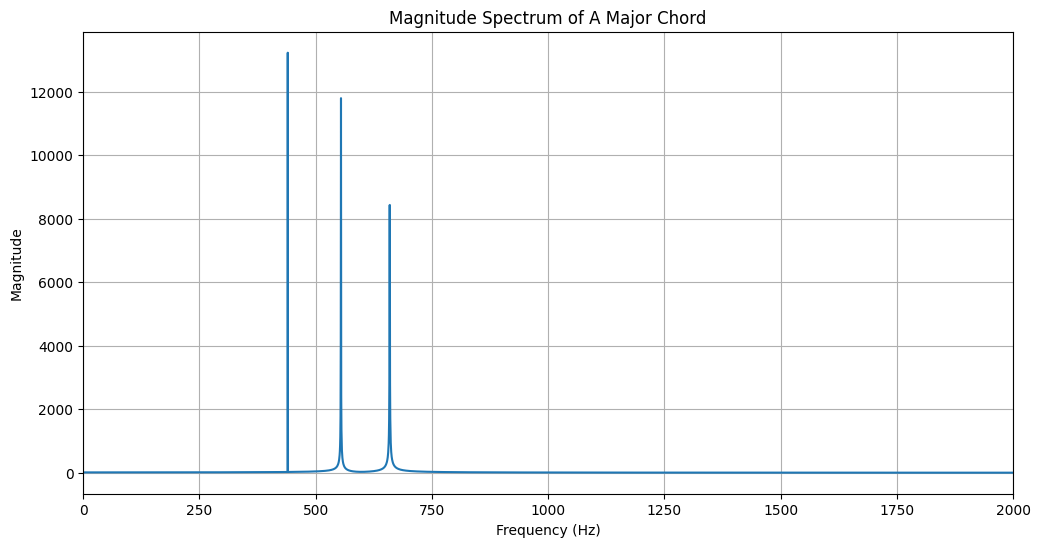


Top 5 Dominant Frequencies and their Magnitudes:
Frequency: 554.00 Hz, Magnitude: 4164.54
Frequency: 659.00 Hz, Magnitude: 8414.45
Frequency: 659.50 Hz, Magnitude: 8430.47
Frequency: 554.50 Hz, Magnitude: 11791.06
Frequency: 440.00 Hz, Magnitude: 13221.89


In [ ]:
# --- Example of Extracting Frequency Domain Features ---

# Use the 'chord' generated earlier for analysis
audio_signal_to_analyze = chord
sampling_rate_analyze = sr

# Apply a window function (e.g., Hann window) to reduce spectral leakage
# For simplicity, we'll omit it here, but it's important in real applications.
N = len(audio_signal_to_analyze)
yf = np.fft.fft(audio_signal_to_analyze)
xf = np.fft.fftfreq(N, 1 / sampling_rate_analyze)

# Only consider the positive frequencies (first half of the spectrum)
positive_frequencies = xf[:N // 2]
magnitude_spectrum = np.abs(yf[:N // 2])

# Plot the magnitude spectrum
plt.figure(figsize=(12, 6))
plt.plot(positive_frequencies, magnitude_spectrum)
plt.title("Magnitude Spectrum of A Major Chord")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 2000) # Limit x-axis to common musical frequencies for better visualization
plt.grid(True)
plt.show()

# Find the dominant frequencies (peaks)
# This is a simple peak finding, more robust methods exist.
peaks_indices = np.argsort(magnitude_spectrum)[-5:] # Get indices of 5 largest peaks
dominant_freqs = positive_frequencies[peaks_indices]
dominant_mags = magnitude_spectrum[peaks_indices]

print("\nTop 5 Dominant Frequencies and their Magnitudes:")
for i in range(len(dominant_freqs)):
    print(f"Frequency: {dominant_freqs[i]:.2f} Hz, Magnitude: {dominant_mags[i]:.2f}")


In [ ]:
import librosa
sr = 22050  # Sample rate
duration = 3  # seconds
frequency = 440  # Hz (A4 note)
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
y = 0.6 * np.sin(2 * np.pi * frequency * t) # 'y' is our audio time-series


print(f"Audio signal loaded/generated: {len(y)} samples, Sample Rate: {sr} Hz")


# --- 2. Calculate MFCCs ---
# n_mfcc: Number of MFCCs to compute. Common values are 12 or 13.
# hop_length: The number of samples between successive frames.
# n_fft: The FFT window size.
# Typically n_fft is 2048, and hop_length is 512 for a 44.1kHz or 22.05kHz audio.
# Adjusting these parameters can affect the resolution and time-frequency trade-off.
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=512, n_fft=2048)


print(f"MFCCs shape: {mfccs.shape}")


Audio signal loaded/generated: 66150 samples, Sample Rate: 22050 Hz
MFCCs shape: (13, 130)


In [ ]:
#Speech Recognition
import speech_recognition as sr
import os

def transcribe_audio_file(audio_file_path):
    """
    Transcribes an audio file into text using Google's Web Speech API.

    Args:
        audio_file_path (str): The path to the audio file (e.g., .wav, .flac, .aiff).

    Returns:
        str: The transcribed text, or an error message if recognition fails.
    """
    r = sr.Recognizer()

    if not os.path.exists(audio_file_path):
        return f"Error: Audio file not found at '{audio_file_path}'"

    with sr.AudioFile(audio_file_path) as source:
        print(f"Reading audio from: {audio_file_path}...")
        audio_data = r.record(source)

    try:
        print("Transcribing audio... (This may take a moment)")
        text = r.recognize_google(audio_data)
        return f"Transcription: \"{text}\""
    except sr.UnknownValueError:
        return "Speech Recognition could not understand audio"
    except sr.RequestError as e:
        return f"Could not request results from Google Web Speech API service; {e}"
    except Exception as e:
        return f"An unexpected error occurred: {e}"

if __name__ == "__main__":
    s = transcribe_audio_file("/content/drive/MyDrive/Applied ML/SpeechToText.wav")
    print(s)

Reading audio from: /content/drive/MyDrive/Applied ML/SpeechToText.wav...
Transcribing audio... (This may take a moment)
Transcription: "and lots of times you need to give people more than one Lincoln a time you banned could give their fans a couple new videos from a live concert behind the scenes photo gallery and album to purchase like these next few links"


In [ ]:
!pip install SpeechRecognition pydub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 65.3 MB/s eta 0:00:00


In [ ]:
import scipy.io.wavfile as wavfile
import matplotlib.pyplot as plt
import numpy as np

# Example: Reading a WAV file
# Assume 'audio.wav' is a sample audio file in the same directory
try:
    sampling_rate, audio_data = wavfile.read('/content/drive/MyDrive/Applied ML/BAK.wav')
    print(f"Sampling Rate: {sampling_rate} Hz")
    print(f"Audio Data Shape: {audio_data.shape}")
    print(f"First 10 samples: {audio_data[:10]}")
except FileNotFoundError:
    print("Error: 'audio.wav' not found. Please make sure you have an audio file named 'audio.wav' in the same directory.")


Sampling Rate: 44100 Hz
Audio Data Shape: (367538, 2)
First 10 samples: [[   9   27]
 [   5   13]
 [  -6   -2]
 [ -23  -26]
 [ -33  -45]
 [ -43  -65]
 [ -70  -80]
 [ -97  -85]
 [-114  -90]
 [-129  -97]]


/tmp/ipython-input-1-942562948.py:8: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sampling_rate, audio_data = wavfile.read('/content/drive/MyDrive/Applied ML/BAK.wav')


/tmp/ipython-input-1-2354800254.py:29: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sampling_rate, audio_data = wavfile.read(filename)


Successfully loaded '/content/drive/MyDrive/Applied ML/BAK.wav'
Sampling Rate: 44100 Hz
Original Audio Data Shape: (367538, 2)
Converted stereo to mono by taking the first channel.
Duration: 8.33 seconds


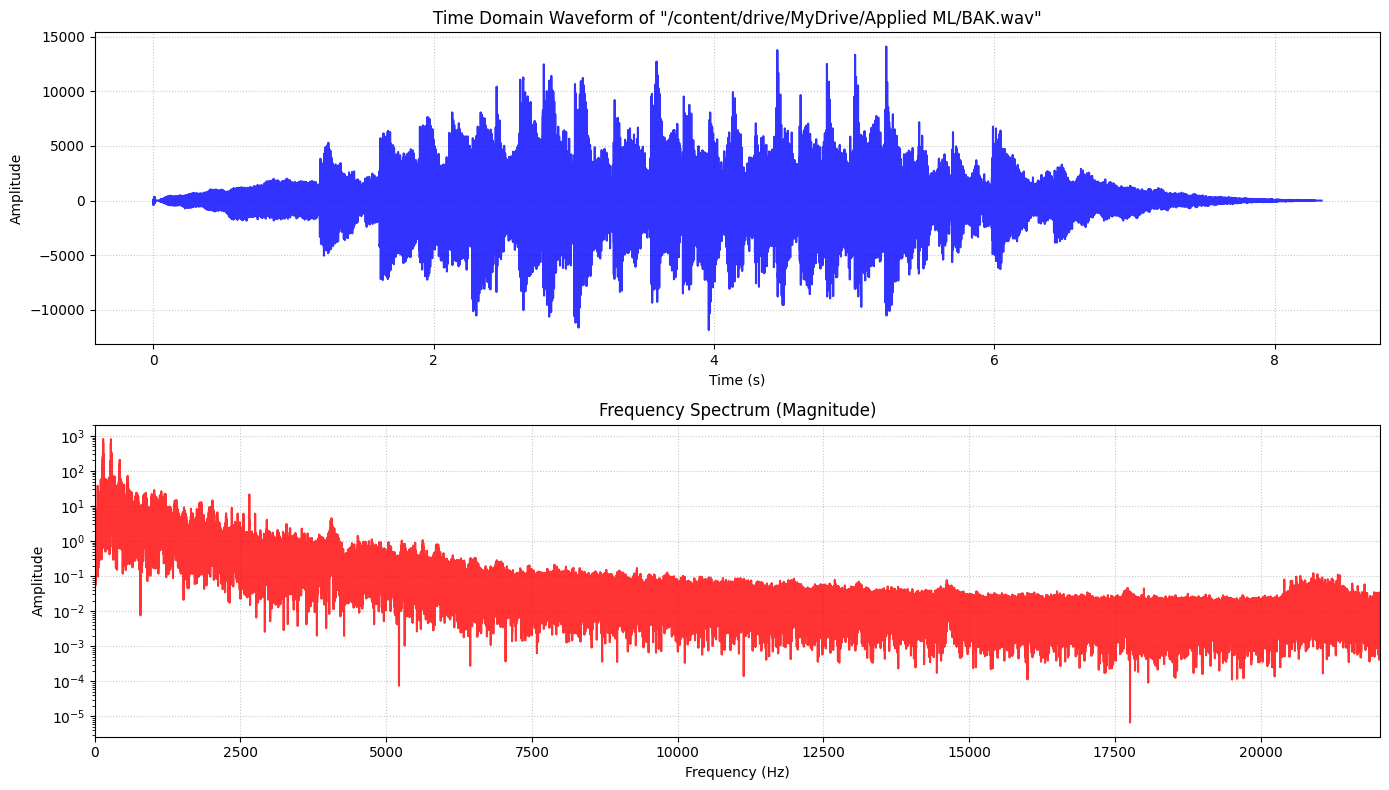


If '/content/drive/MyDrive/Applied ML/BAK.wav' did not exist, a dummy file was created for demonstration.
You can replace 'my_audio_file.wav' with the path to your own WAV file.


In [ ]:
import scipy.io.wavfile as wavfile
import numpy as np
import matplotlib.pyplot as plt
import os # To check if a file exists

def wav_to_fourier_transform_and_visualize(filename):
    """
    Reads a WAV file, computes its Fast Fourier Transform (FFT),
    and plots both the time-domain waveform and the frequency spectrum.

    Args:
        filename (str): The path to the WAV file.
    """
    if not os.path.exists(filename):
        print(f"Error: The file '{filename}' was not found.")
        print("Please ensure the WAV file exists in the specified path.")
        print("Creating a dummy WAV file for demonstration...")
        print(f"Dummy file '{filename}' created. Retrying analysis.")
        # Recursively call the function with the newly created dummy file
        # Or you could just proceed with the dummy data here
        # For simplicity, let's just proceed with the dummy data immediately
        # after creation, rather than re-calling.
        # So we'll move the data reading into the else block below
        pass # The actual reading will happen in the try block below

    try:
        # 1. Read the WAV file
        sampling_rate, audio_data = wavfile.read(filename)
        print(f"Successfully loaded '{filename}'")
        print(f"Sampling Rate: {sampling_rate} Hz")
        print(f"Original Audio Data Shape: {audio_data.shape}")

        # If stereo, take only one channel (e.g., the first channel)
        if audio_data.ndim > 1:
            audio_data = audio_data[:, 0]
            print("Converted stereo to mono by taking the first channel.")

        num_samples = len(audio_data)
        duration = num_samples / sampling_rate
        print(f"Duration: {duration:.2f} seconds")

        if num_samples == 0:
            print("Warning: The audio file contains no samples. Cannot perform FFT.")
            return

        # 2. Plot the Time-Domain Waveform
        time_axis = np.linspace(0, duration, num=num_samples, endpoint=False)

        plt.figure(figsize=(14, 8)) # Increased figure height for better layout

        plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot (waveform)
        plt.plot(time_axis, audio_data, color='blue', alpha=0.8)
        plt.title(f'Time Domain Waveform of "{filename}"')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.tight_layout() # Adjust layout for current subplot

        # 3. Compute the FFT (Fast Fourier Transform)
        # The FFT output is complex, representing magnitude and phase for each frequency.
        # We perform the FFT on the entire signal.
        fft_output = np.fft.fft(audio_data)

        # 4. Calculate the frequencies corresponding to the FFT output bins
        # `fftfreq` helps map the bin indices to actual frequencies
        frequencies = np.fft.fftfreq(num_samples, d=1/sampling_rate)

        # 5. Extract magnitude (amplitude spectrum) and consider only positive frequencies
        # The magnitude is the absolute value of the complex FFT output
        magnitudes = np.abs(fft_output) / num_samples # Normalize by number of samples

        # Select only the positive frequencies and their corresponding magnitudes
        positive_freq_indices = frequencies >= 0
        positive_frequencies = frequencies[positive_freq_indices]
        positive_magnitudes = magnitudes[positive_freq_indices]

        # For all frequencies except the DC (0 Hz) and Nyquist (if present and even num_samples),
        # the energy is split between positive and negative components, so we multiply by 2.
        # The 0 Hz (DC component) is not doubled.
        # The Nyquist frequency (sampling_rate / 2) if it falls exactly on a bin (for even N)
        # is also not doubled.

        # Double the magnitudes for all non-DC, non-Nyquist components
        # We start from index 1 to skip the DC component (0 Hz)
        # We check if num_samples is even to handle the Nyquist frequency properly
        if num_samples % 2 == 0:
            # If N is even, the Nyquist frequency component is at index N/2 and is not duplicated
            positive_magnitudes[1:-1] *= 2 # Double all except 0 Hz and Nyquist
        else:
            # If N is odd, there is no explicit Nyquist component, and all other positive frequencies are doubled
            positive_magnitudes[1:] *= 2 # Double all except 0 Hz

        # 6. Plot the Frequency Spectrum (Magnitude)
        plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot (frequency spectrum)
        plt.plot(positive_frequencies, positive_magnitudes, color='red', alpha=0.8)
        plt.title('Frequency Spectrum (Magnitude)')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Amplitude')
        plt.xlim(0, sampling_rate / 2) # Limit x-axis to Nyquist frequency
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.semilogy() # Use a logarithmic scale for the y-axis for better visibility of lower amplitudes

        plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
        plt.show()

    except Exception as e:
        print(f"An error occurred during processing: {e}")
        print("Please ensure the WAV file is valid and not corrupted.")




# --- Main Execution ---
if __name__ == "__main__":
    # Define your WAV file name here
    # Make sure this file exists in the same directory as your script,
    # or provide the full path to it.
    audio_file_name = "/content/drive/MyDrive/Applied ML/BAK.wav"

    # Call the function to process and visualize
    wav_to_fourier_transform_and_visualize(audio_file_name)

    print(f"\nIf '{audio_file_name}' did not exist, a dummy file was created for demonstration.")
    print("You can replace 'my_audio_file.wav' with the path to your own WAV file.")

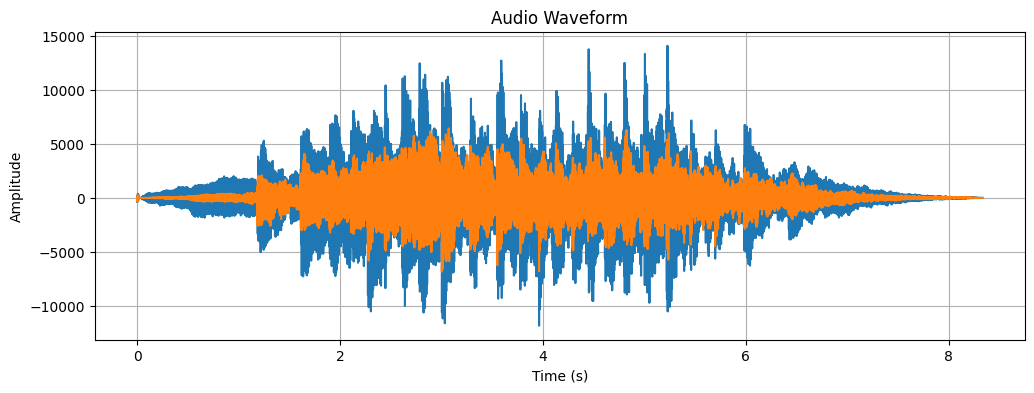

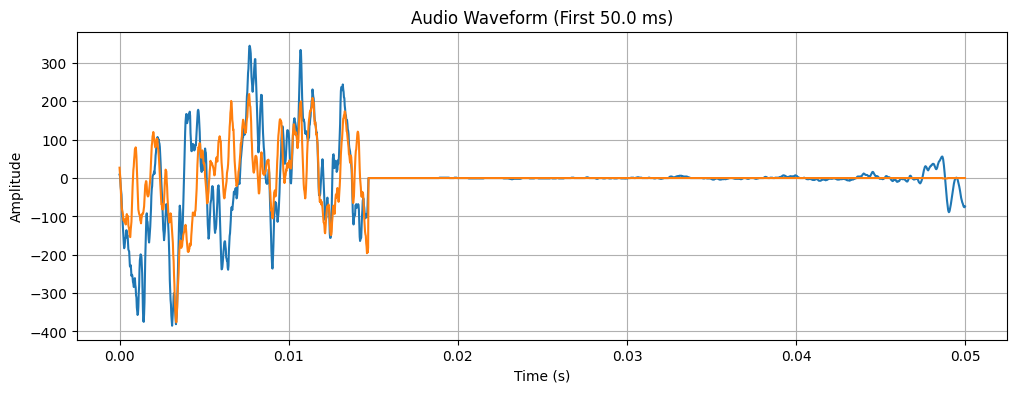

In [ ]:
if 'audio_data' in locals():
    time = np.linspace(0, len(audio_data) / sampling_rate, num=len(audio_data))

    plt.figure(figsize=(12, 4))
    plt.plot(time, audio_data)
    plt.title('Audio Waveform')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()

    # Plotting a short segment for more detail
    segment_duration = 0.05 # seconds
    segment_samples = int(segment_duration * sampling_rate)
    plt.figure(figsize=(12, 4))
    plt.plot(time[:segment_samples], audio_data[:segment_samples])
    plt.title(f'Audio Waveform (First {segment_duration*1000} ms)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()


Audio signal loaded/generated: 66150 samples, Sample Rate: 22050 Hz
MFCCs shape: (13, 130)


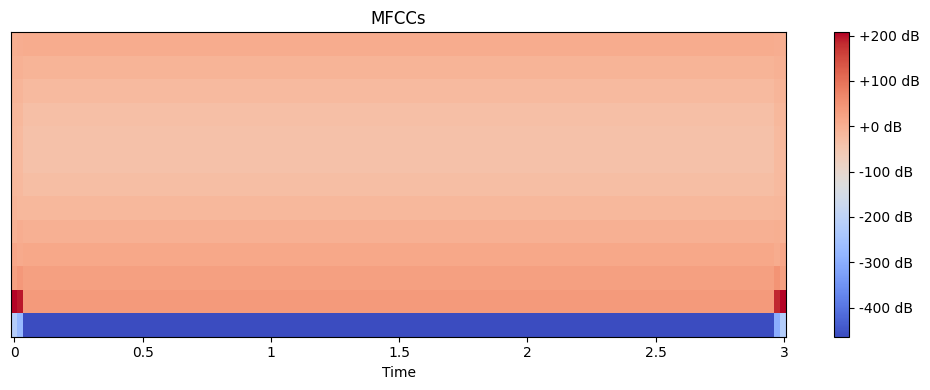


Mean MFCCs (across time): [-457.65462369   42.82500166   28.52655931   14.07254792   -2.12030315
  -17.78907948  -30.11211737  -37.27081668  -38.22830903  -32.9588863
  -22.53539747   -8.8841308     5.69854349]
MFCC Delta shape: (13, 130)
MFCC Delta-Delta shape: (13, 130)


In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf # For saving generated audio if needed

# --- 1. Load an Audio File (or generate a dummy signal) ---
# For demonstration, let's create a simple sine wave as our audio input.
# In a real application, you would load an audio file like this:
# audio_file_path = librosa.ex('trumpet') # Example file from librosa
# y, sr = librosa.load(audio_file_path, sr=None) # Load with original sampling rate

# Generate a dummy audio signal (e.g., a 440 Hz sine wave)
sr = 22050  # Sample rate
duration = 3  # seconds
frequency = 440  # Hz (A4 note)
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
y = 0.6 * np.sin(2 * np.pi * frequency * t) # 'y' is our audio time-series

print(f"Audio signal loaded/generated: {len(y)} samples, Sample Rate: {sr} Hz")

# --- 2. Calculate MFCCs ---
# n_mfcc: Number of MFCCs to compute. Common values are 12 or 13.
# hop_length: The number of samples between successive frames.
# n_fft: The FFT window size.
# Typically n_fft is 2048, and hop_length is 512 for a 44.1kHz or 22.05kHz audio.
# Adjusting these parameters can affect the resolution and time-frequency trade-off.
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=512, n_fft=2048)

print(f"MFCCs shape: {mfccs.shape}")
# The shape is (n_mfcc, number_of_frames)

# --- 3. Visualize the MFCCs ---
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, x_axis='time', sr=sr, hop_length=512)
plt.colorbar(format='%+2.0f dB')
plt.title('MFCCs')
plt.tight_layout()
plt.show()

# --- Optional: Further processing or analysis ---
# You can now use these 'mfccs' for machine learning tasks, e.g.,
# for classification (speech vs. music, identifying instruments),
# or for similarity comparisons.

# Example: Calculate the mean MFCCs across time for a compact representation
mean_mfccs = np.mean(mfccs, axis=1)
print(f"\nMean MFCCs (across time): {mean_mfccs}")

# Example: You could also calculate the delta (first derivative) and delta-delta (second derivative) MFCCs
# which capture information about how the MFCCs are changing over time.
mfccs_delta = librosa.feature.delta(mfccs)
mfccs_delta2 = librosa.feature.delta(mfccs, order=2)

print(f"MFCC Delta shape: {mfccs_delta.shape}")
print(f"MFCC Delta-Delta shape: {mfccs_delta2.shape}")

# Concatenate them if you want to use all three for a feature vector
# mfccs_full = np.concatenate((mfccs, mfccs_delta, mfccs_delta2), axis=0)
# print(f"Full MFCCs (MFCCs + Delta + Delta-Delta) shape: {mfccs_full.shape}")